# Gradient Stability: Understanding Exploding and Vanishing Gradients

**Learning Objectives:**
- Understand why gradients explode or vanish in deep neural networks
- Observe these phenomena through hands-on experiments
- Learn how activation functions, initialization, and architecture affect gradient flow
- Master techniques to stabilize training: gradient clipping, batch normalization, residual connections
- Develop strong intuitions about what makes deep networks trainable

**Philosophy:** This notebook is a laboratory. We'll build networks, break them, fix them, and understand exactly why each intervention works. Theory will precede every experiment, and you'll be asked to predict outcomes before seeing results.

## Part 1: Setup and Introduction

### What Are Gradient Flow Problems?

When training deep neural networks with backpropagation, we compute gradients layer by layer, moving from output to input. Two catastrophic problems can occur:

1. **Vanishing Gradients**: Gradients become exponentially smaller as they propagate backward, eventually becoming so small that early layers barely learn
2. **Exploding Gradients**: Gradients become exponentially larger, causing unstable updates and divergent training

These problems prevented training of deep networks until solutions were discovered. Let's understand why they happen and how to fix them.

In [1]:
# Standard imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset

# Set style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

Initialize the experiment setup.

In [2]:
# Import shared utilities
from aiml_notebooks import get_device, set_seed

# Setup
set_seed(42)
device = get_device()

Using MPS (Metal Performance Shaders) for GPU acceleration


## Part 2: The Chain Rule Foundation

### Why Do Gradients Multiply Through Layers?

Consider a simple 3-layer network:

```
x → w₁ → a₁ → w₂ → a₂ → w₃ → a₃ → loss
```

By the chain rule, the gradient of the loss with respect to the first layer's weights is:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a_3} \cdot \frac{\partial a_3}{\partial a_2} \cdot \frac{\partial a_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial w_1}$$

**Key Insight**: Each layer contributes a multiplicative factor to the gradient. If these factors are:
- Consistently < 1: The product shrinks exponentially (vanishing)
- Consistently > 1: The product grows exponentially (exploding)

For a network with $n$ layers, if each layer contributes a factor of $f$:
- $f = 0.5$ for 10 layers → gradient scaled by $0.5^{10} \approx 0.001$
- $f = 2.0$ for 10 layers → gradient scaled by $2^{10} = 1024$

Let's see this mathematically with a simple activation function.

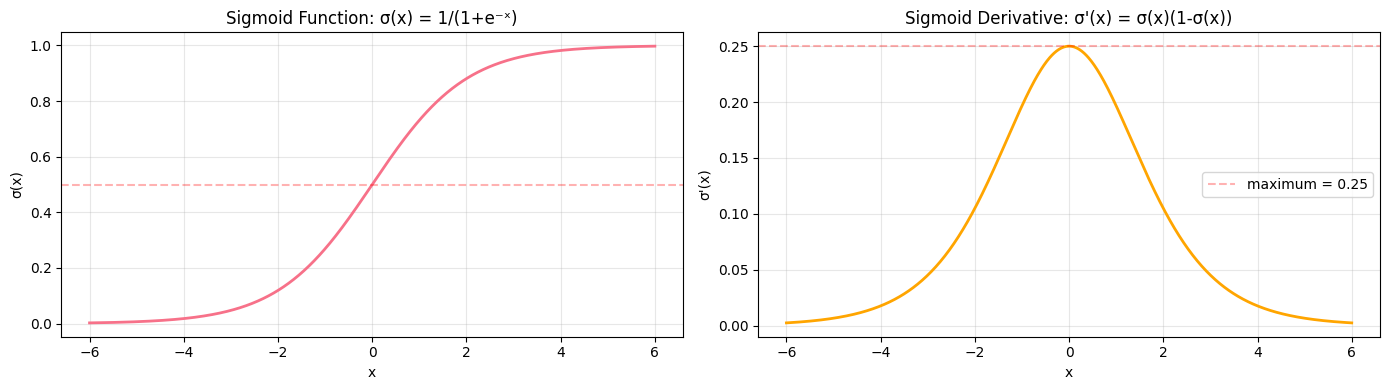

Maximum sigmoid derivative: 0.2500

For a 10-layer sigmoid network:
  Gradient scaling (best case): 0.25^10 = 9.54e-07
  Gradient scaling (typical): 0.2^10 = 1.02e-07


In [3]:
# Visualize sigmoid and its derivative
x = np.linspace(-6, 6, 1000)
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_derivative = sigmoid * (1 - sigmoid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(x, sigmoid, linewidth=2)
ax1.set_title('Sigmoid Function: σ(x) = 1/(1+e⁻ˣ)', fontsize=12)
ax1.set_xlabel('x')
ax1.set_ylabel('σ(x)')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='midpoint')

ax2.plot(x, sigmoid_derivative, linewidth=2, color='orange')
ax2.set_title("Sigmoid Derivative: σ'(x) = σ(x)(1-σ(x))", fontsize=12)
ax2.set_xlabel('x')
ax2.set_ylabel("σ'(x)")
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.25, color='r', linestyle='--', alpha=0.3, label='maximum = 0.25')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Maximum sigmoid derivative: {sigmoid_derivative.max():.4f}")
print(f"\nFor a 10-layer sigmoid network:")
print(f"  Gradient scaling (best case): 0.25^10 = {0.25**10:.2e}")
print(f"  Gradient scaling (typical): 0.2^10 = {0.2**10:.2e}")

### 🤔 Reflection Question

Why is the maximum derivative of sigmoid only 0.25? What happens to the derivative when the input is very large or very small (saturated regions)?

<details>
<summary>Click to reveal answer</summary>

The derivative σ'(x) = σ(x)(1-σ(x)) is maximized when σ(x) = 0.5 (at x=0), giving 0.5 × 0.5 = 0.25.

When x is very large (σ→1) or very small (σ→0), the derivative approaches 0. This is called "saturation" - the neuron becomes insensitive to its inputs, and gradients can't flow through it.
</details>

## Part 3: Building a Deep Network Sandbox

We'll create a flexible MLP class that lets us experiment with:
- Different depths (number of layers)
- Different activation functions
- Different initialization strategies
- Optional batch normalization
- Optional residual connections

This will be our experimental testbed.

In [4]:
class FlexibleMLP(nn.Module):
    """Flexible MLP for experimenting with gradient flow.
    
    Args:
        input_dim: Input feature dimension
        hidden_dim: Hidden layer dimension
        output_dim: Output dimension
        num_layers: Number of hidden layers
        activation: Activation function name ('sigmoid', 'tanh', 'relu', 'leaky_relu')
        use_batchnorm: Whether to use batch normalization
        use_residual: Whether to use residual connections (requires input_dim == hidden_dim)
        init_strategy: Initialization strategy ('default', 'xavier', 'he', 'large', 'small')
    """
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers,
                 activation='relu', use_batchnorm=False, use_residual=False,
                 init_strategy='default'):
        super().__init__()
        
        self.num_layers = num_layers
        self.use_batchnorm = use_batchnorm
        self.use_residual = use_residual
        self.activation_name = activation
        
        # Build layers
        self.layers = nn.ModuleList()
        self.batchnorms = nn.ModuleList() if use_batchnorm else None
        
        # First layer
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        if use_batchnorm:
            self.batchnorms.append(nn.BatchNorm1d(hidden_dim))
        
        # Hidden layers
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
            if use_batchnorm:
                self.batchnorms.append(nn.BatchNorm1d(hidden_dim))
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        
        # Select activation
        self.activation = self._get_activation(activation)
        
        # Initialize weights
        self._initialize_weights(init_strategy)
        
        # For residual connections, ensure dimensions match
        if use_residual and input_dim != hidden_dim:
            self.input_projection = nn.Linear(input_dim, hidden_dim)
        else:
            self.input_projection = None
    
    def _get_activation(self, name):
        activations = {
            'sigmoid': torch.sigmoid,
            'tanh': torch.tanh,
            'relu': F.relu,
            'leaky_relu': lambda x: F.leaky_relu(x, 0.2)
        }
        return activations[name]
    
    def _initialize_weights(self, strategy):
        for layer in self.layers:
            if strategy == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
            elif strategy == 'he':
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            elif strategy == 'large':
                nn.init.uniform_(layer.weight, -2.0, 2.0)
            elif strategy == 'small':
                nn.init.uniform_(layer.weight, -0.01, 0.01)
            # 'default' uses PyTorch's default initialization
            
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)
        
        # Output layer always uses default
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)
    
    def forward(self, x):
        # First layer
        if self.use_residual:
            if self.input_projection is not None:
                identity = self.input_projection(x)
            else:
                identity = x
        else:
            identity = None
        
        x = self.layers[0](x)
        if self.use_batchnorm:
            x = self.batchnorms[0](x)
        x = self.activation(x)
        
        # Add residual connection after first layer if enabled
        if self.use_residual:
            x = x + identity
        
        # Hidden layers with optional residual connections
        for i in range(1, self.num_layers):
            if self.use_residual:
                identity = x
            
            x = self.layers[i](x)
            if self.use_batchnorm:
                x = self.batchnorms[i](x)
            x = self.activation(x)
            
            if self.use_residual:
                x = x + identity  # Skip connection
        
        # Output layer
        x = self.output_layer(x)
        return x

print("✓ FlexibleMLP class created")

✓ FlexibleMLP class created


### Create Synthetic Dataset

We'll use a simple synthetic classification task - two interleaved spirals. The task is challenging enough to require deep networks but simple enough to train quickly.

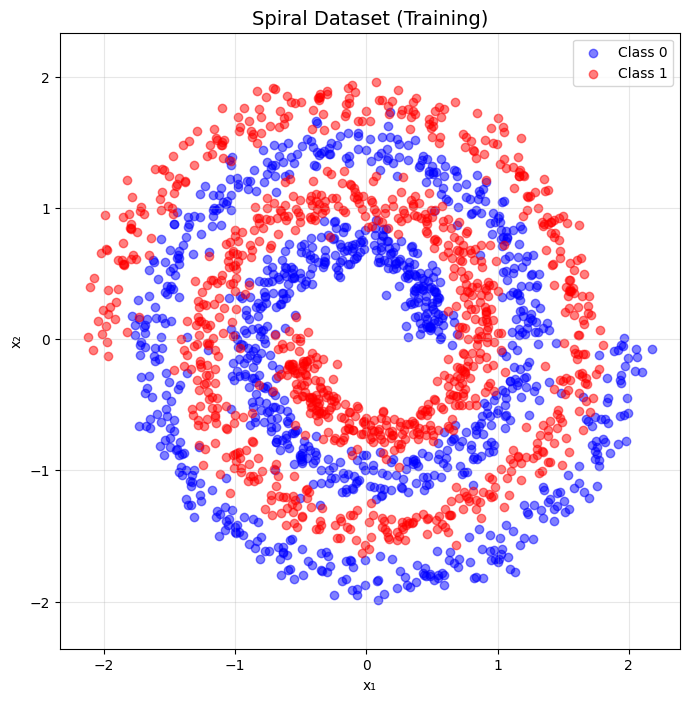

Training samples: 2000
Test samples: 400
Input dimension: 2


In [5]:
def generate_spiral_data(n_samples=1000, noise=0.1):
    """Generate two interleaved spirals for binary classification."""
    n = n_samples // 2
    
    # Generate spiral 1
    theta1 = np.linspace(0, 4 * np.pi, n)
    r1 = np.linspace(0.5, 2, n)
    x1 = r1 * np.cos(theta1) + np.random.randn(n) * noise
    y1 = r1 * np.sin(theta1) + np.random.randn(n) * noise
    
    # Generate spiral 2 (offset by π)
    theta2 = np.linspace(0, 4 * np.pi, n) + np.pi
    r2 = np.linspace(0.5, 2, n)
    x2 = r2 * np.cos(theta2) + np.random.randn(n) * noise
    y2 = r2 * np.sin(theta2) + np.random.randn(n) * noise
    
    # Combine
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.hstack([np.zeros(n), np.ones(n)])
    
    return torch.FloatTensor(X), torch.LongTensor(y)

# Generate data
X_train, y_train = generate_spiral_data(n_samples=2000)
X_test, y_test = generate_spiral_data(n_samples=400)

# Create dataloaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# Visualize
plt.figure(figsize=(8, 8))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', alpha=0.5, label='Class 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='red', alpha=0.5, label='Class 1')
plt.title('Spiral Dataset (Training)', fontsize=14)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input dimension: {X_train.shape[1]}")

## Part 4: Gradient Tracking Utilities

To observe gradient flow, we need to:
1. Hook into the backward pass
2. Capture gradient magnitudes at each layer
3. Track these over training steps
4. Visualize as heatmaps and line plots

In [6]:
class GradientTracker:
    """Track gradient magnitudes during training."""
    
    def __init__(self, model):
        self.model = model
        self.gradient_history = defaultdict(list)
        self.step = 0
        self.hooks = []
        self._register_hooks()
    
    def _register_hooks(self):
        """Register backward hooks on all linear layers."""
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                hook = module.weight.register_hook(
                    lambda grad, n=name: self._save_gradient(n, grad)
                )
                self.hooks.append(hook)
    
    def _save_gradient(self, name, grad):
        """Save gradient norm for a layer."""
        if grad is not None:
            norm = grad.norm().item()
            self.gradient_history[name].append((self.step, norm))
    
    def step_forward(self):
        """Increment step counter."""
        self.step += 1
    
    def get_history(self):
        """Return gradient history as dict."""
        return dict(self.gradient_history)
    
    def remove_hooks(self):
        """Remove all hooks."""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

print("✓ GradientTracker class created")

✓ GradientTracker class created


Visualize the results with multiple plots for comparison.

In [7]:
def plot_gradient_flow(gradient_history, title="Gradient Flow", max_steps=None):
    """Plot gradient magnitudes as heatmap and line plots."""
    if not gradient_history:
        print("No gradient history to plot")
        return

    # Extract data - sort numerically by layer index, with output_layer at the end
    def get_layer_sort_key(name):
        """Get sort key for layer name.
        Returns (is_numbered_layer, layer_index) for proper sorting.
        Numbered layers come first, then non-numbered layers like 'output_layer'.
        """
        try:
            # Try to extract numeric index (e.g., 'layers.10' -> 10)
            index = int(name.split('.')[-1])
            return (0, index)  # 0 means numbered layer, sort by index
        except (ValueError, IndexError):
            # Non-numbered layer (e.g., 'output_layer') goes to the end
            return (1, 0)  # 1 means non-numbered, comes after all numbered layers
    
    layer_names = sorted(gradient_history.keys(), key=get_layer_sort_key)

    # Build matrix: rows = layers, cols = steps
    all_steps = set()
    for layer_data in gradient_history.values():
        all_steps.update(step for step, _ in layer_data)
    all_steps = sorted(all_steps)

    if max_steps:
        all_steps = all_steps[:max_steps]

    gradient_matrix = np.zeros((len(layer_names), len(all_steps)))
    gradient_matrix.fill(np.nan)  # Initialize with NaN instead of zeros

    for i, layer_name in enumerate(layer_names):
        step_to_grad = {step: grad for step, grad in gradient_history[layer_name]}
        for j, step in enumerate(all_steps):
            if step in step_to_grad:
                grad_value = step_to_grad[step]
                # Filter out NaN and inf values
                if np.isfinite(grad_value) and grad_value > 0:
                    gradient_matrix[i, j] = grad_value

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Check for valid (finite, positive) values
    valid_mask = np.isfinite(gradient_matrix) & (gradient_matrix > 0)
    
    if not valid_mask.any():
        print(f"⚠️ Warning: No valid gradients to plot for {title}")
        print("   All gradients are NaN, inf, or zero. This indicates exploding gradients.")
        print("   Try: gradient clipping, better initialization, or lower learning rate.")
        plt.close(fig)
        return

    # Heatmap - use safe values for LogNorm
    valid_grads = gradient_matrix[valid_mask]
    grad_min = valid_grads.min()
    grad_max = valid_grads.max()

    # Only use LogNorm if we have valid positive values
    if grad_max > grad_min and grad_min > 0:
        # Replace NaN/inf with a small value for visualization
        display_matrix = np.where(valid_mask, gradient_matrix, grad_min * 0.1)
        im = ax1.imshow(display_matrix, aspect='auto', cmap='viridis',
                        norm=plt.matplotlib.colors.LogNorm(vmin=grad_min, vmax=grad_max))
    else:
        # Fallback to linear norm if gradients are problematic
        display_matrix = np.where(valid_mask, gradient_matrix, 0)
        im = ax1.imshow(display_matrix, aspect='auto', cmap='viridis')

    ax1.set_yticks(range(len(layer_names)))
    ax1.set_yticklabels([name.split('.')[-1] for name in layer_names], fontsize=8)
    ax1.set_xlabel('Training Step', fontsize=11)
    ax1.set_ylabel('Layer', fontsize=11)
    ax1.set_title(f'{title} - Gradient Magnitude Heatmap', fontsize=12)
    plt.colorbar(im, ax=ax1, label='Gradient Norm (log scale)')

    # Line plot - filter out invalid values
    for i, layer_name in enumerate(layer_names):
        valid_data = [(s, g) for s, g in gradient_history[layer_name] 
                      if s in all_steps and np.isfinite(g) and g > 0]
        if valid_data:
            steps, grads = zip(*valid_data)
            ax2.plot(steps, grads, label=layer_name.split('.')[-1], alpha=0.7)

    ax2.set_xlabel('Training Step', fontsize=11)
    ax2.set_ylabel('Gradient Norm', fontsize=11)
    ax2.set_title(f'{title} - Gradient Evolution', fontsize=12)

    # Only use log scale if we have positive gradients
    if grad_max > 0:
        ax2.set_yscale('log')
    ax2.legend(fontsize=8, loc='best')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✓ Visualization function created")

✓ Visualization function created


Train the model and monitor progress.

In [8]:
def train_with_tracking(model, train_loader, epochs=5, lr=0.01, 
                       gradient_clip=None, track_gradients=True):
    """Train model and track gradients."""
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    if track_gradients:
        tracker = GradientTracker(model)
    else:
        tracker = None
    
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            
            # Optional gradient clipping
            if gradient_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            
            optimizer.step()
            
            if tracker:
                tracker.step_forward()
            
            epoch_loss += loss.item()
        
        losses.append(epoch_loss / len(train_loader))
    
    if tracker:
        gradient_history = tracker.get_history()
        tracker.remove_hooks()
    else:
        gradient_history = None
    
    return losses, gradient_history

print("✓ Training function created")

✓ Training function created


## Part 5: Observing Vanishing Gradients

### Experiment 1: Deep Network with Sigmoid Activation

**Hypothesis**: A deep network (20 layers) with sigmoid activation will suffer from vanishing gradients. Early layers will receive tiny gradients and won't learn.

**Prediction Question**: Before running the cell below, think:
- What will the gradient heatmap look like?
- Which layers will have the smallest gradients?
- Will the network train successfully?

Model: 20 layers with sigmoid activation


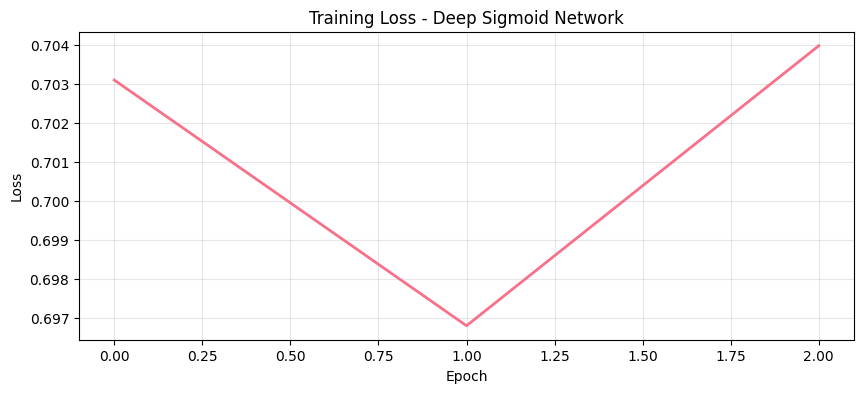

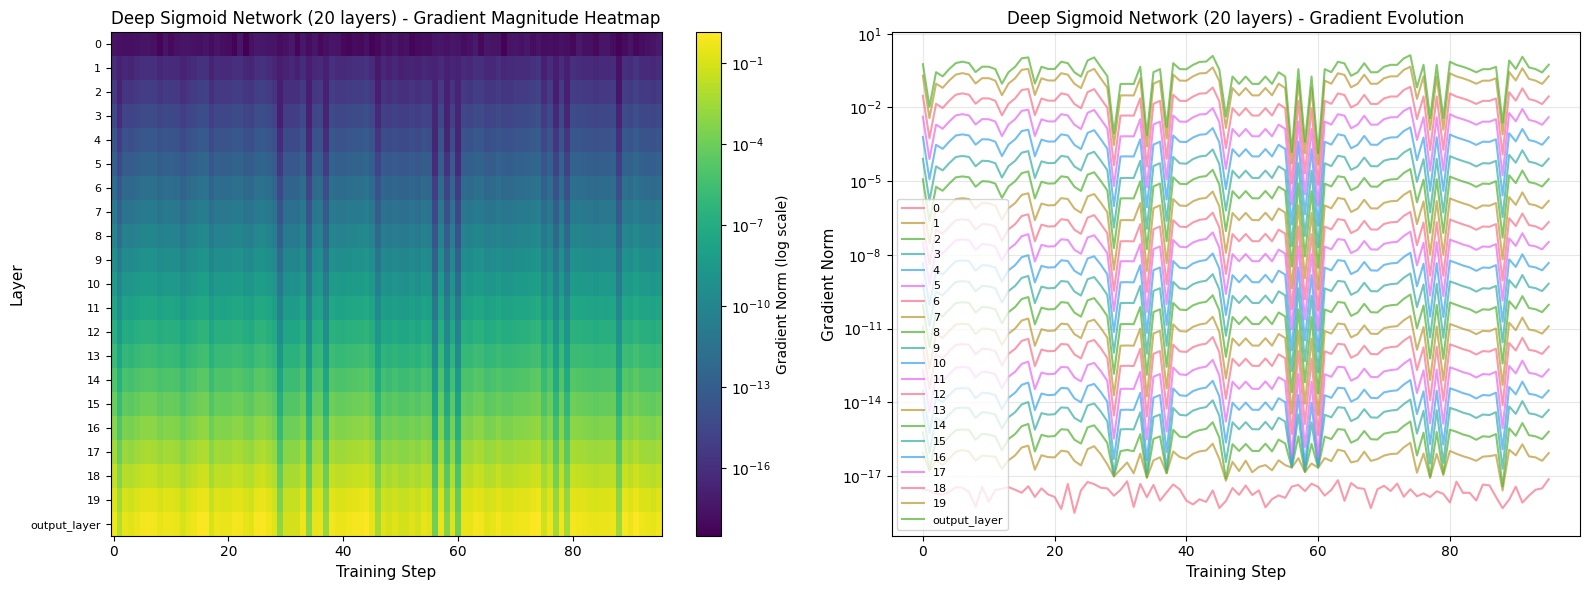

In [9]:
# Create deep sigmoid network
model_sigmoid_deep = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=20,
    activation='sigmoid'
)

print(f"Model: {model_sigmoid_deep.num_layers} layers with {model_sigmoid_deep.activation_name} activation")

# Train and track
losses, grad_history = train_with_tracking(
    model_sigmoid_deep, 
    train_loader, 
    epochs=3,
    lr=0.1
)

# Plot results
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss - Deep Sigmoid Network', fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

# Plot gradient flow
plot_gradient_flow(grad_history, title="Deep Sigmoid Network (20 layers)", max_steps=200)

### 🔍 Observations

Look at the gradient heatmap:
- **Early layers** (bottom of heatmap): Gradients are extremely small (dark blue/purple)
- **Later layers** (top of heatmap): Gradients are larger (brighter colors)
- **Line plot**: Early layers have gradients orders of magnitude smaller than later layers

This is the **vanishing gradient problem** in action. The gradients are shrinking exponentially as they propagate backward through sigmoid layers.

### 🤔 Reflection Questions

1. Why are the earliest layers affected most severely?
2. What would happen if we trained for 100 epochs instead of 3?
3. How would a 3-layer network compare?

<details>
<summary>Click for answers</summary>

1. Early layers are furthest from the loss, so gradients must pass through the most sigmoid derivatives (each ≤ 0.25), causing exponential decay.
2. Training longer wouldn't help much - the early layers simply can't receive useful gradient signal to learn.
3. A 3-layer network would have much less gradient shrinkage and train more successfully.
</details>

### Experiment 2: Shallow vs Deep Comparison

Let's verify our intuition by comparing 3-layer vs 20-layer sigmoid networks side-by-side.

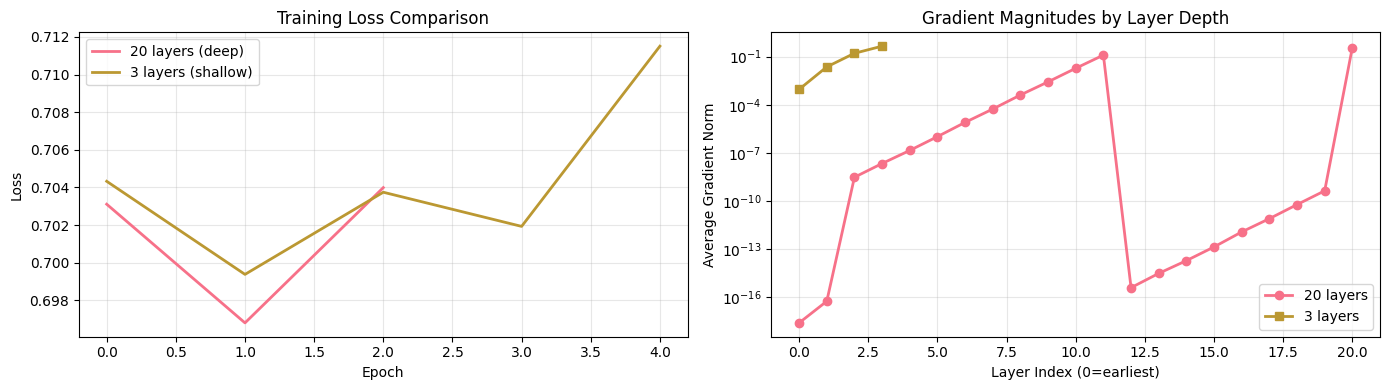


Final loss (20 layers): 0.7040
Final loss (3 layers): 0.7115

Gradient ratio (first/last layer):
  20 layers: 7.24e-18
  3 layers: 2.05e-03


In [10]:
# Shallow network
model_sigmoid_shallow = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=3,
    activation='sigmoid'
)

losses_shallow, grad_history_shallow = train_with_tracking(
    model_sigmoid_shallow,
    train_loader,
    epochs=5,
    lr=0.1
)

# Compare losses
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses, linewidth=2, label='20 layers (deep)')
ax1.plot(losses_shallow, linewidth=2, label='3 layers (shallow)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Compare final gradient norms
def get_average_gradients(grad_history):
    layer_names = sorted(grad_history.keys())
    avg_grads = []
    for name in layer_names:
        grads = [g for _, g in grad_history[name][-50:]]  # Last 50 steps
        avg_grads.append(np.mean(grads))
    return layer_names, avg_grads

names_deep, grads_deep = get_average_gradients(grad_history)
names_shallow, grads_shallow = get_average_gradients(grad_history_shallow)

ax2.plot(grads_deep, 'o-', linewidth=2, label='20 layers', markersize=6)
ax2.plot(grads_shallow, 's-', linewidth=2, label='3 layers', markersize=6)
ax2.set_xlabel('Layer Index (0=earliest)')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('Gradient Magnitudes by Layer Depth', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal loss (20 layers): {losses[-1]:.4f}")
print(f"Final loss (3 layers): {losses_shallow[-1]:.4f}")
print(f"\nGradient ratio (first/last layer):")
print(f"  20 layers: {grads_deep[0]/grads_deep[-1]:.2e}")
print(f"  3 layers: {grads_shallow[0]/grads_shallow[-1]:.2e}")

**Key Insight**: The shallow network trains better because gradients can flow more easily through fewer layers. The deep network's early layers have gradients ~1000x smaller than the shallow network's!

## Part 6: Observing Exploding Gradients

### Experiment 3: Large Weight Initialization

**Hypothesis**: If we initialize weights to be very large, gradients will multiply to huge values, causing exploding gradients.

**Prediction Question**: What will happen to:
- The training loss curve?
- The gradient magnitudes?
- The model's ability to learn?

Model: 10 layers with ReLU, large initialization


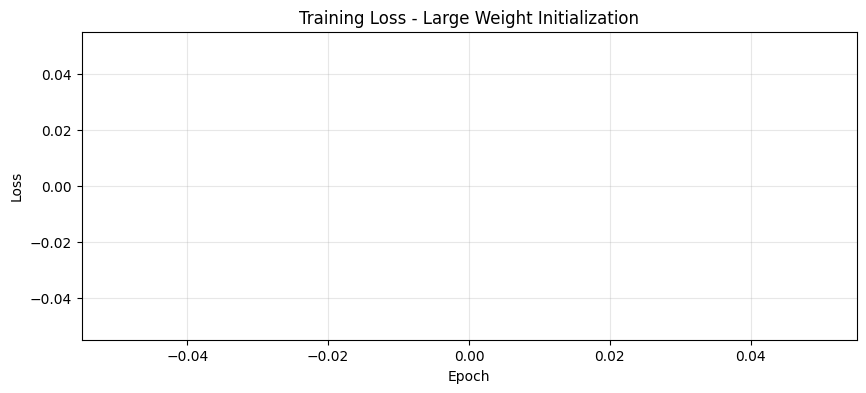

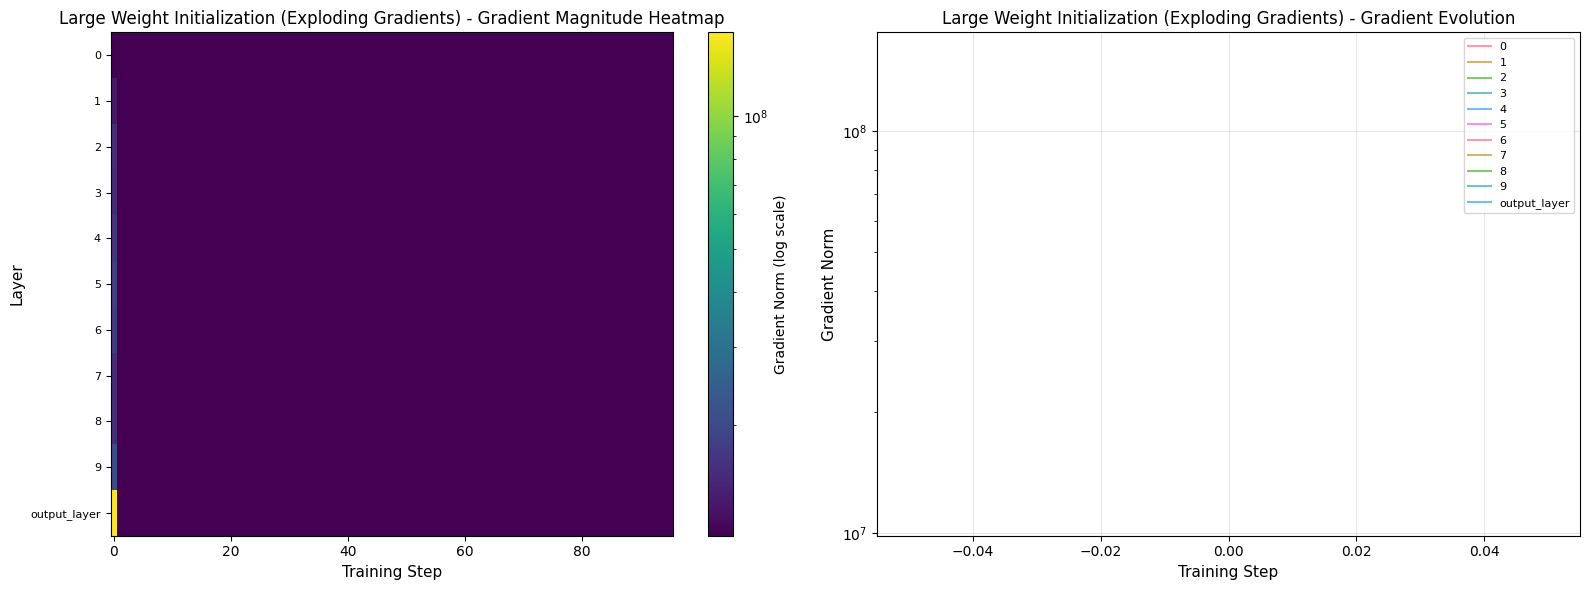

In [11]:
# Network with large weight initialization
model_exploding = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=10,
    activation='relu',
    init_strategy='large'  # Weights initialized in [-2, 2]
)

print(f"Model: {model_exploding.num_layers} layers with ReLU, large initialization")

# Train
losses_exploding, grad_history_exploding = train_with_tracking(
    model_exploding,
    train_loader,
    epochs=3,
    lr=0.01
)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_exploding, linewidth=2, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss - Large Weight Initialization', fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

# Gradients
plot_gradient_flow(grad_history_exploding, 
                  title="Large Weight Initialization (Exploding Gradients)",
                  max_steps=100)

### 🔍 Observations

- **Loss curve**: Likely shows instability - may spike up or diverge to NaN
- **Gradient heatmap**: Very bright colors indicating huge gradients (possibly >1000)
- **Training**: Unstable and ineffective

This is the **exploding gradient problem**. When weights are large and activations don't saturate, gradients multiply to enormous values, causing:
1. Unstable parameter updates
2. Loss divergence
3. Potential NaN values

### 🤔 Reflection Question

Why does ReLU with large weights cause explosion, while sigmoid with large weights causes vanishing?

<details>
<summary>Click for answer</summary>

ReLU's derivative is 1 for positive inputs (no saturation), so large weights → large activations → large gradients that multiply through layers.

Sigmoid saturates for large inputs (derivative → 0), so large weights initially cause saturation → tiny gradients → vanishing.
</details>

## Part 7: The Role of Activation Functions

### Why ReLU Helps

ReLU and its variants don't suffer from the saturation problem:
- Sigmoid derivative: max 0.25, often much smaller
- Tanh derivative: max 1.0, often much smaller  
- **ReLU derivative: 1 for positive inputs, 0 for negative**
- **Leaky ReLU derivative: 1 for positive, 0.2 for negative**

Let's visualize this.

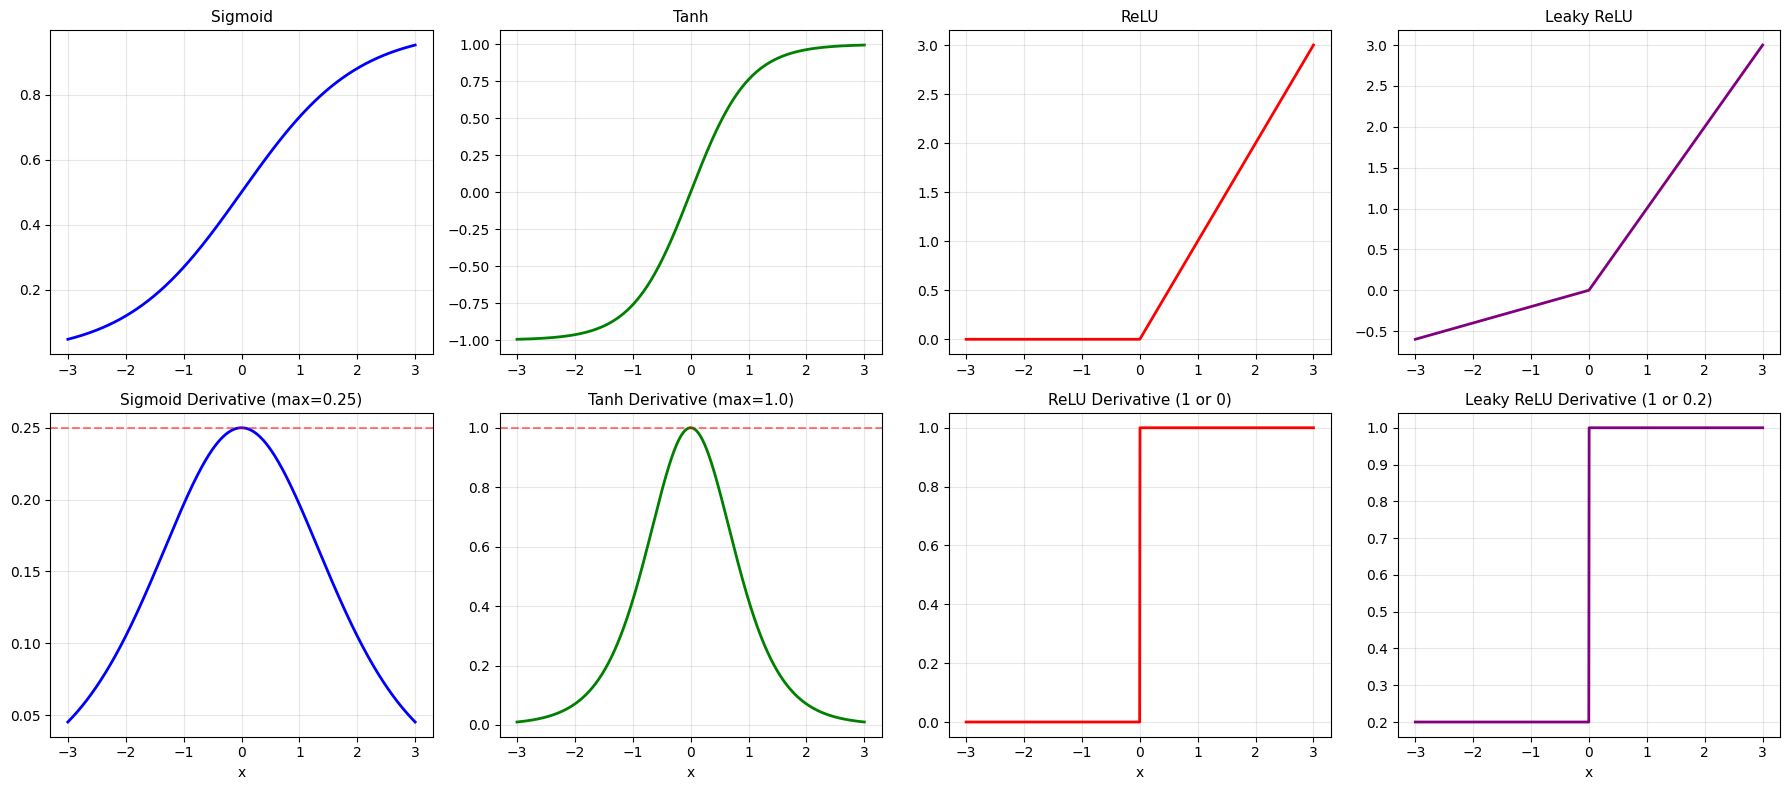

Key differences:
  Sigmoid/Tanh: Saturate for large |x|, derivatives → 0
  ReLU: No saturation for x > 0, derivative = 1 (preserves gradients!)
  Leaky ReLU: Allows small gradient even for x < 0 (avoids 'dying ReLU')


In [12]:
# Compare activation functions and their derivatives
x = np.linspace(-3, 3, 1000)

# Functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.2 * x)

# Derivatives
sigmoid_deriv = sigmoid * (1 - sigmoid)
tanh_deriv = 1 - tanh**2
relu_deriv = np.where(x > 0, 1, 0)
leaky_relu_deriv = np.where(x > 0, 1, 0.2)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Plot functions
axes[0, 0].plot(x, sigmoid, linewidth=2, color='blue')
axes[0, 0].set_title('Sigmoid', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x, tanh, linewidth=2, color='green')
axes[0, 1].set_title('Tanh', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(x, relu, linewidth=2, color='red')
axes[0, 2].set_title('ReLU', fontsize=11)
axes[0, 2].grid(True, alpha=0.3)

axes[0, 3].plot(x, leaky_relu, linewidth=2, color='purple')
axes[0, 3].set_title('Leaky ReLU', fontsize=11)
axes[0, 3].grid(True, alpha=0.3)

# Plot derivatives
axes[1, 0].plot(x, sigmoid_deriv, linewidth=2, color='blue')
axes[1, 0].set_title('Sigmoid Derivative (max=0.25)', fontsize=11)
axes[1, 0].axhline(y=0.25, color='r', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel('x')

axes[1, 1].plot(x, tanh_deriv, linewidth=2, color='green')
axes[1, 1].set_title('Tanh Derivative (max=1.0)', fontsize=11)
axes[1, 1].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('x')

axes[1, 2].plot(x, relu_deriv, linewidth=2, color='red')
axes[1, 2].set_title('ReLU Derivative (1 or 0)', fontsize=11)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xlabel('x')

axes[1, 3].plot(x, leaky_relu_deriv, linewidth=2, color='purple')
axes[1, 3].set_title('Leaky ReLU Derivative (1 or 0.2)', fontsize=11)
axes[1, 3].grid(True, alpha=0.3)
axes[1, 3].set_xlabel('x')

plt.tight_layout()
plt.show()

print("Key differences:")
print("  Sigmoid/Tanh: Saturate for large |x|, derivatives → 0")
print("  ReLU: No saturation for x > 0, derivative = 1 (preserves gradients!)")
print("  Leaky ReLU: Allows small gradient even for x < 0 (avoids 'dying ReLU')")

### Experiment 4: Deep ReLU Network

**Hypothesis**: A deep network with ReLU will train much better than the same network with sigmoid.

Let's test this with proper initialization.

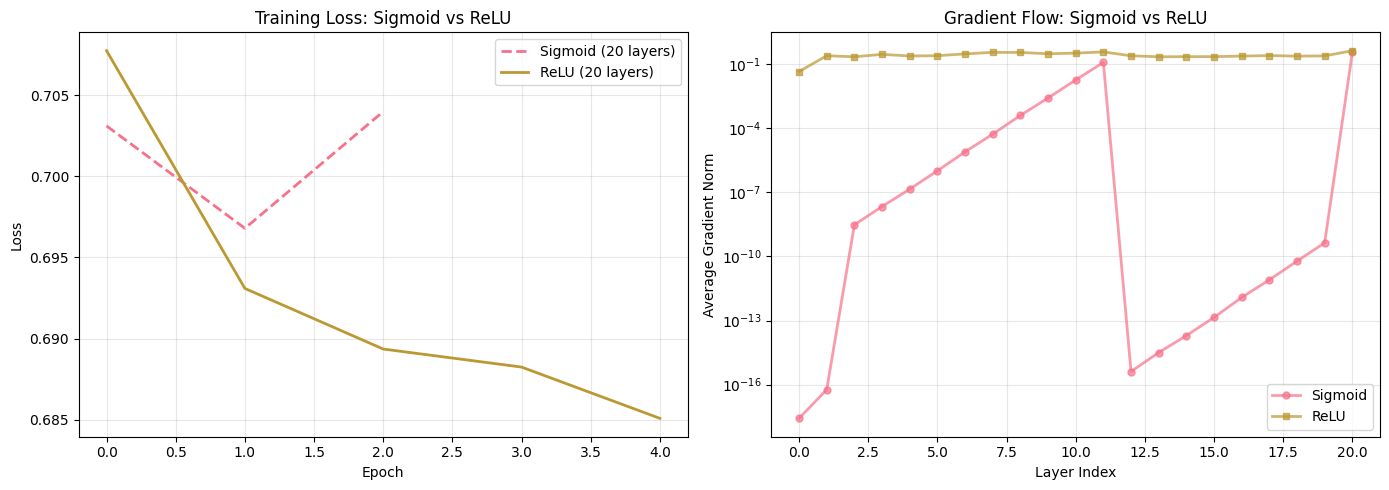


Final Loss:
  Sigmoid: 0.7040
  ReLU: 0.6851

Gradient uniformity (std/mean across layers):
  Sigmoid: 3.31
  ReLU: 0.28


In [13]:
# Deep ReLU network with default initialization
model_relu_deep = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=20,
    activation='relu',
    init_strategy='he'  # He initialization for ReLU
)

losses_relu, grad_history_relu = train_with_tracking(
    model_relu_deep,
    train_loader,
    epochs=5,
    lr=0.01
)

# Compare with sigmoid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
ax1.plot(losses, linewidth=2, label='Sigmoid (20 layers)', linestyle='--')
ax1.plot(losses_relu, linewidth=2, label='ReLU (20 layers)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss: Sigmoid vs ReLU', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradient comparison
names_relu, grads_relu = get_average_gradients(grad_history_relu)
ax2.plot(grads_deep, 'o-', linewidth=2, label='Sigmoid', alpha=0.7, markersize=5)
ax2.plot(grads_relu, 's-', linewidth=2, label='ReLU', alpha=0.7, markersize=5)
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('Gradient Flow: Sigmoid vs ReLU', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Loss:")
print(f"  Sigmoid: {losses[-1]:.4f}")
print(f"  ReLU: {losses_relu[-1]:.4f}")
print(f"\nGradient uniformity (std/mean across layers):")
print(f"  Sigmoid: {np.std(grads_deep)/np.mean(grads_deep):.2f}")
print(f"  ReLU: {np.std(grads_relu)/np.mean(grads_relu):.2f}")

### 🔍 Key Observations

ReLU enables much more uniform gradient flow:
- Gradients don't vanish exponentially
- All layers receive meaningful learning signals
- Training loss decreases much more effectively

This is why ReLU and its variants (Leaky ReLU, PReLU, ELU, GELU) are the default choice for deep networks.

## Part 8: The Role of Initialization

### Theory: Variance Preservation

For stable gradient flow, we want to preserve variance of:
- **Activations** during forward pass
- **Gradients** during backward pass

**Xavier/Glorot Initialization** (for tanh/sigmoid):
- Initialize weights: $W \sim \mathcal{U}\left[-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right]$
- Keeps variance constant for symmetric activations

**He Initialization** (for ReLU):
- Initialize weights: $W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$
- Accounts for the fact that ReLU zeros out half the neurons

Let's see the difference!

### Experiment 5: Initialization Strategies for Tanh Networks

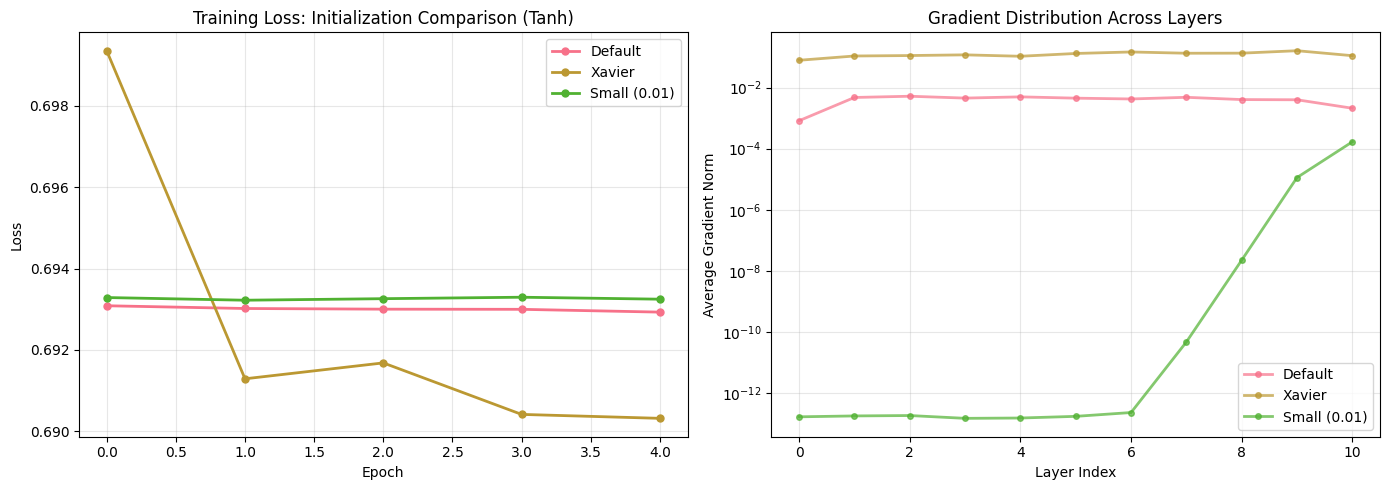

Final losses:
  Default        : 0.6929
  Xavier         : 0.6903
  Small (0.01)   : 0.6932


In [14]:
# Compare initialization strategies on tanh network
configs = [
    ('Default', 'default'),
    ('Xavier', 'xavier'),
    ('Small (0.01)', 'small'),
]

results = {}

for name, init_strategy in configs:
    model = FlexibleMLP(
        input_dim=2,
        hidden_dim=64,
        output_dim=2,
        num_layers=10,
        activation='tanh',
        init_strategy=init_strategy
    )
    
    losses, grad_history = train_with_tracking(
        model, train_loader, epochs=5, lr=0.01
    )
    
    results[name] = {
        'losses': losses,
        'grad_history': grad_history
    }

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Losses
for name, data in results.items():
    ax1.plot(data['losses'], linewidth=2, label=name, marker='o', markersize=5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss: Initialization Comparison (Tanh)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradients by layer
for name, data in results.items():
    _, grads = get_average_gradients(data['grad_history'])
    ax2.plot(grads, linewidth=2, label=name, marker='o', markersize=4, alpha=0.7)
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('Gradient Distribution Across Layers', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final losses:")
for name, data in results.items():
    print(f"  {name:15s}: {data['losses'][-1]:.4f}")

### 🔍 Key Observations

- **Xavier initialization**: Best for tanh - balanced gradients across layers
- **Default initialization**: Works reasonably well
- **Too small**: Gradients vanish even more severely

Proper initialization doesn't solve the fundamental saturation problem of tanh/sigmoid, but it helps networks start in a better state.

### Experiment 6: He Initialization for ReLU

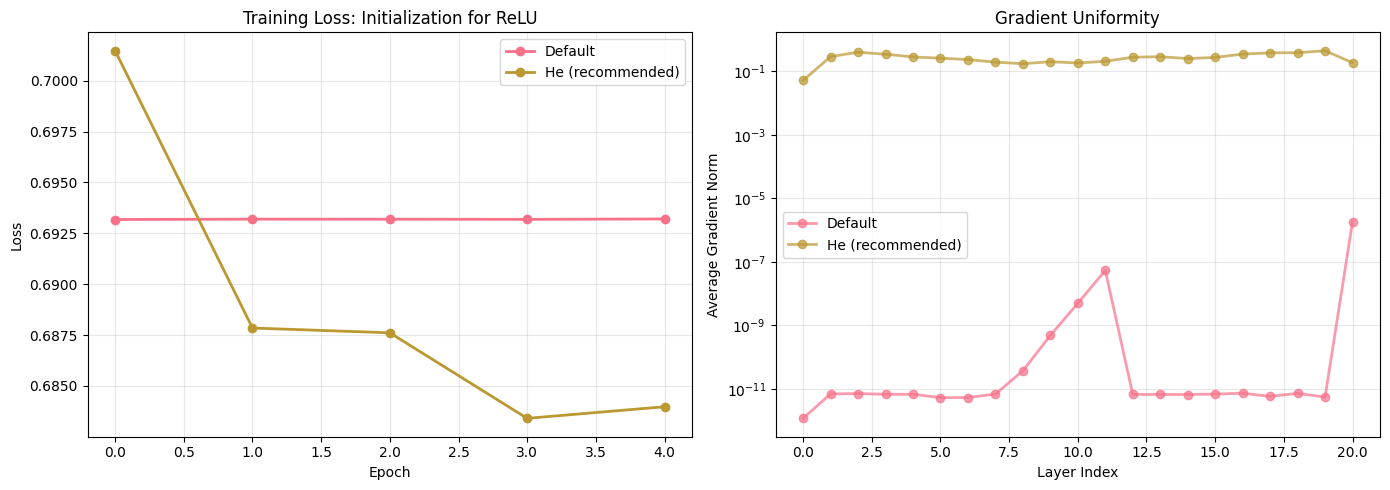

In [15]:
# Compare He vs default for ReLU
configs_relu = [
    ('Default', 'default'),
    ('He (recommended)', 'he'),
]

results_relu = {}

for name, init_strategy in configs_relu:
    model = FlexibleMLP(
        input_dim=2,
        hidden_dim=64,
        output_dim=2,
        num_layers=20,
        activation='relu',
        init_strategy=init_strategy
    )
    
    losses, grad_history = train_with_tracking(
        model, train_loader, epochs=5, lr=0.01
    )
    
    results_relu[name] = {
        'losses': losses,
        'grad_history': grad_history
    }

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results_relu.items():
    ax1.plot(data['losses'], linewidth=2, label=name, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss: Initialization for ReLU', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

for name, data in results_relu.items():
    _, grads = get_average_gradients(data['grad_history'])
    ax2.plot(grads, linewidth=2, label=name, marker='o', alpha=0.7)
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('Gradient Uniformity', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary: Initialization Best Practices

| Activation | Recommended Init | Why |
|------------|------------------|-----|
| Sigmoid/Tanh | Xavier/Glorot | Preserves variance for symmetric activations |
| ReLU/Leaky ReLU | He | Accounts for half the neurons being zeroed |
| Linear (no activation) | Xavier | Preserves variance exactly |

## Part 9: Gradient Clipping

### Solution for Exploding Gradients

When gradients explode, we can **clip** them to a maximum norm:

$$\text{if } ||g|| > \text{threshold}: \quad g \leftarrow g \cdot \frac{\text{threshold}}{||g||}$$

This caps the gradient magnitude while preserving direction.

### Experiment 7: Gradient Clipping in Action

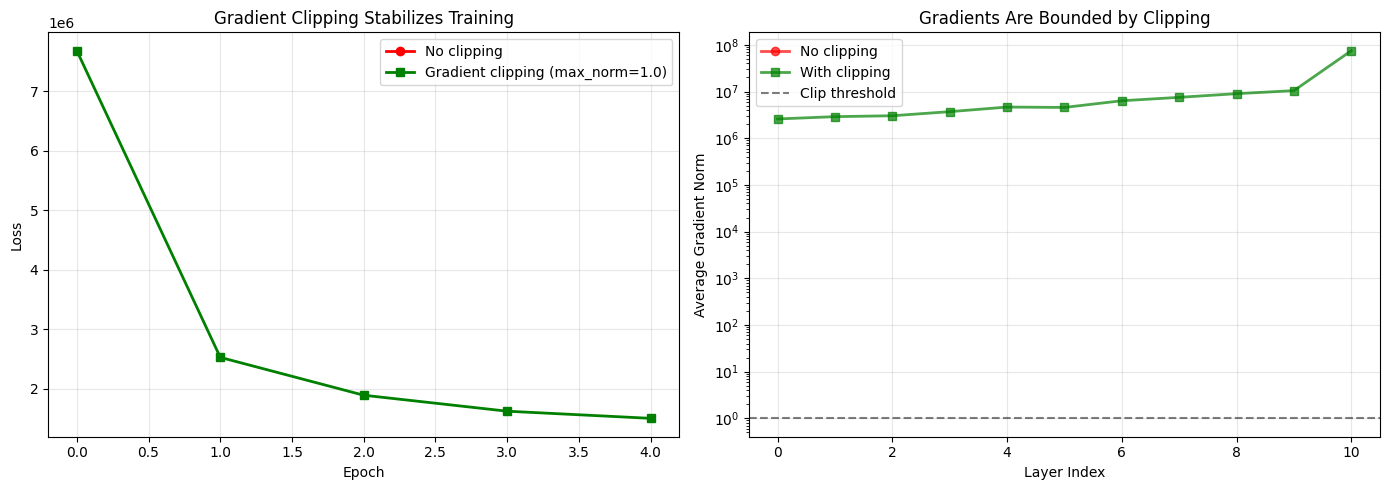

Final loss (no clipping): nan
Final loss (with clipping): 1504770.0742


In [16]:
# Train model with large init, with and without clipping
model_no_clip = FlexibleMLP(
    input_dim=2, hidden_dim=64, output_dim=2, num_layers=10,
    activation='relu', init_strategy='large'
)

model_with_clip = FlexibleMLP(
    input_dim=2, hidden_dim=64, output_dim=2, num_layers=10,
    activation='relu', init_strategy='large'
)

# No clipping
losses_no_clip, grad_history_no_clip = train_with_tracking(
    model_no_clip, train_loader, epochs=5, lr=0.01, gradient_clip=None
)

# With clipping
losses_with_clip, grad_history_with_clip = train_with_tracking(
    model_with_clip, train_loader, epochs=5, lr=0.01, gradient_clip=1.0
)

# Compare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses_no_clip, linewidth=2, label='No clipping', marker='o', color='red')
ax1.plot(losses_with_clip, linewidth=2, label='Gradient clipping (max_norm=1.0)', 
         marker='s', color='green')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Gradient Clipping Stabilizes Training', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradient magnitudes
_, grads_no_clip = get_average_gradients(grad_history_no_clip)
_, grads_with_clip = get_average_gradients(grad_history_with_clip)

ax2.plot(grads_no_clip, linewidth=2, label='No clipping', marker='o', 
         alpha=0.7, color='red')
ax2.plot(grads_with_clip, linewidth=2, label='With clipping', marker='s', 
         alpha=0.7, color='green')
ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Clip threshold')
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('Gradients Are Bounded by Clipping', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss (no clipping): {losses_no_clip[-1]:.4f}")
print(f"Final loss (with clipping): {losses_with_clip[-1]:.4f}")

### 🔍 Observations

- **Without clipping**: Training may be unstable, loss may spike
- **With clipping**: Gradients capped at threshold, stable training

Gradient clipping is essential for:
- Recurrent networks (RNNs, LSTMs) where gradients can explode over time
- Any network with poorly conditioned loss surfaces
- Training with high learning rates

### 🤔 Reflection Question

Does gradient clipping solve the root cause of exploding gradients, or just treat the symptom?

<details>
<summary>Click for answer</summary>

It treats the symptom. The root cause is poor initialization, inappropriate activation functions, or architectural issues. Clipping prevents training from diverging, but better initialization and architecture design are preferable solutions.
</details>

## Part 10: Batch Normalization

### Theory: Normalizing Activations

**Batch Normalization** normalizes layer inputs to have mean=0, variance=1:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

Then learns affine transformation: $y = \gamma \hat{x} + \beta$

**Benefits**:
1. Prevents activation distribution shift (internal covariate shift)
2. Reduces sensitivity to initialization
3. Allows higher learning rates
4. Acts as regularization (noise from batch statistics)

### Experiment 8: Deep Network with Batch Normalization

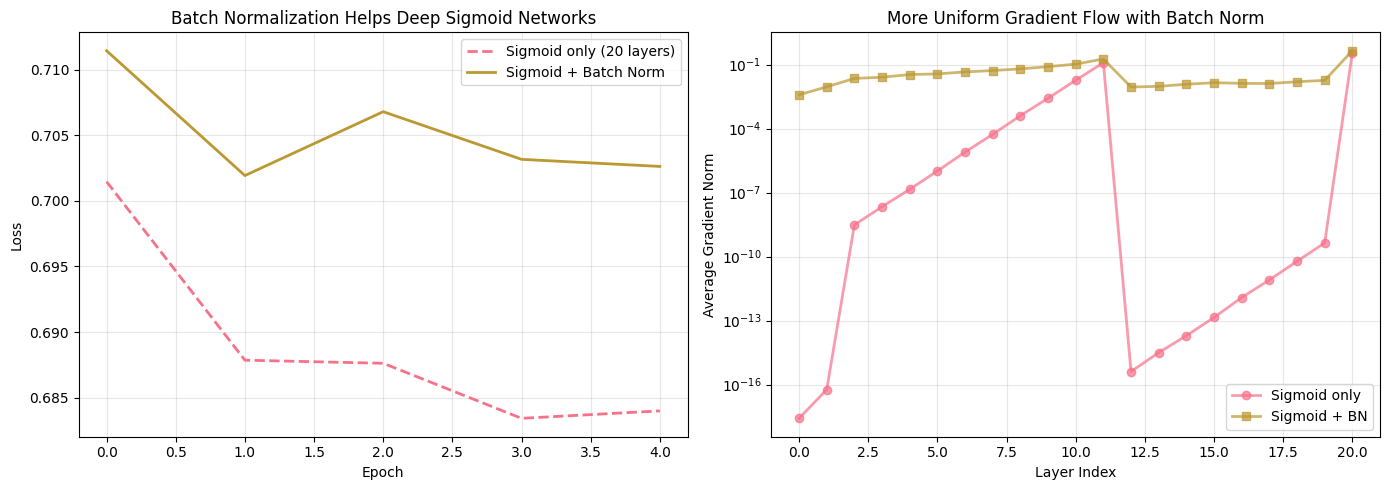

Final loss (Sigmoid only): 0.6840
Final loss (Sigmoid + BN): 0.7026


In [17]:
# Deep sigmoid network with batch norm
model_sigmoid_bn = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=20,
    activation='sigmoid',
    use_batchnorm=True
)

losses_sigmoid_bn, grad_history_sigmoid_bn = train_with_tracking(
    model_sigmoid_bn, train_loader, epochs=5, lr=0.1
)

# Compare with plain sigmoid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses, linewidth=2, label='Sigmoid only (20 layers)', linestyle='--')
ax1.plot(losses_sigmoid_bn, linewidth=2, label='Sigmoid + Batch Norm')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Batch Normalization Helps Deep Sigmoid Networks', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradients
_, grads_sigmoid_bn = get_average_gradients(grad_history_sigmoid_bn)
ax2.plot(grads_deep, 'o-', linewidth=2, label='Sigmoid only', alpha=0.7)
ax2.plot(grads_sigmoid_bn, 's-', linewidth=2, label='Sigmoid + BN', alpha=0.7)
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('More Uniform Gradient Flow with Batch Norm', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss (Sigmoid only): {losses[-1]:.4f}")
print(f"Final loss (Sigmoid + BN): {losses_sigmoid_bn[-1]:.4f}")

### 🔍 Key Observations

Batch normalization dramatically improves training:
- **Gradients**: More uniform across layers
- **Loss**: Decreases much faster
- **Stability**: Can train even with sigmoid!

BN prevents internal covariate shift - each layer's inputs stay in a reasonable range, preventing saturation.

### When to Use Batch Normalization

✅ Use when:
- Training very deep networks
- Using saturating activations (sigmoid/tanh)
- You want to use higher learning rates

❌ Be careful when:
- Batch size is very small (statistics are noisy)
- Using RNNs (use Layer Normalization instead)
- Deploying models (need to handle train/eval mode correctly)

## Part 11: Residual Connections

### Theory: Gradient Highways

**Residual connections** (skip connections) add the input directly to the output:

$$y = F(x) + x$$

where $F(x)$ is the layer transformation.

**Why this helps gradients**:

During backprop:
$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \left(\frac{\partial F(x)}{\partial x} + \frac{\partial x}{\partial x}\right) = \frac{\partial L}{\partial y} \cdot \left(\frac{\partial F(x)}{\partial x} + 1\right)$$

The "+1" term provides a **gradient highway** - gradients can flow directly backward without being attenuated by layer transformations!

This enables networks with 100+ layers (ResNet, Transformers).

### Experiment 9: Extremely Deep Network with Residual Connections

Training 50-layer network WITHOUT residual connections...

Training 50-layer network WITH residual connections + batch norm...


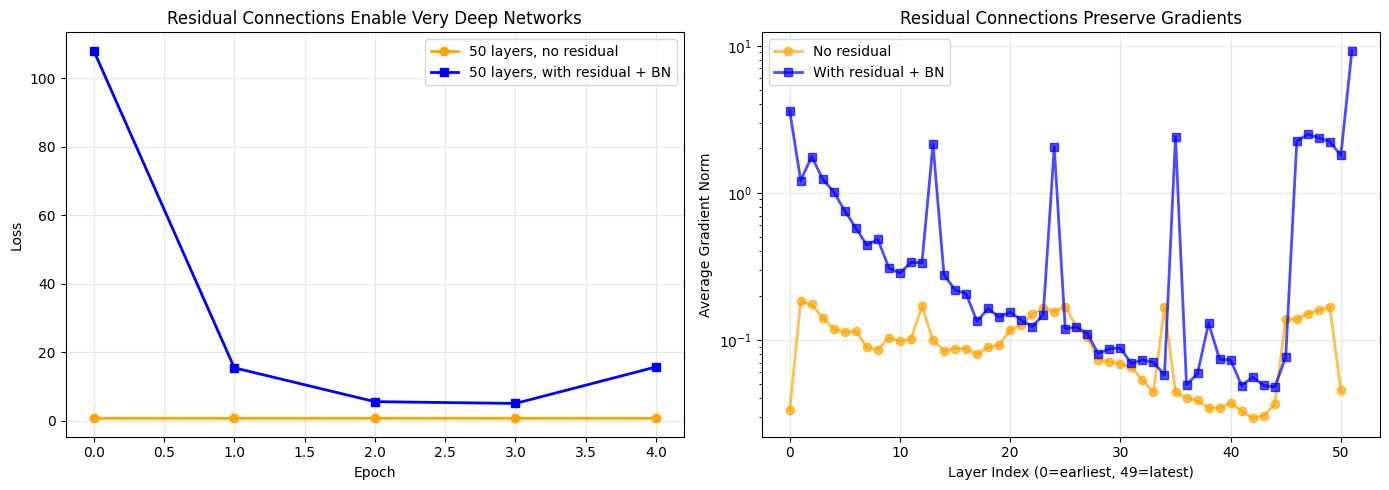


Final loss (no residual): 0.6888
Final loss (with residual + BN): 15.6965

Gradient decay (first layer / last layer):
  No residual: 7.32e-01
  With residual + BN: 3.91e-01


In [ ]:
# Very deep network WITHOUT residual connections
model_deep_no_residual = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=50,
    activation='relu',
    init_strategy='he',
    use_residual=False
)

# Very deep network WITH residual connections (MUST use batch norm for stability!)
model_deep_with_residual = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=50,
    activation='relu',
    init_strategy='he',
    use_residual=True,
    use_batchnorm=True  # Essential for deep residual networks to prevent activation explosion!
)

print("Training 50-layer network WITHOUT residual connections...")
losses_no_res, grad_history_no_res = train_with_tracking(
    model_deep_no_residual, train_loader, epochs=5, lr=0.01
)

print("\nTraining 50-layer network WITH residual connections + batch norm...")
losses_with_res, grad_history_with_res = train_with_tracking(
    model_deep_with_residual, train_loader, epochs=5, lr=0.01
)

# Compare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses_no_res, linewidth=2, label='50 layers, no residual', 
         marker='o', color='orange')
ax1.plot(losses_with_res, linewidth=2, label='50 layers, with residual + BN', 
         marker='s', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Residual Connections Enable Very Deep Networks', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradients
_, grads_no_res = get_average_gradients(grad_history_no_res)
_, grads_with_res = get_average_gradients(grad_history_with_res)

ax2.plot(grads_no_res, linewidth=2, label='No residual', marker='o', 
         alpha=0.7, color='orange')
ax2.plot(grads_with_res, linewidth=2, label='With residual + BN', marker='s', 
         alpha=0.7, color='blue')
ax2.set_xlabel('Layer Index (0=earliest, 49=latest)')
ax2.set_ylabel('Average Gradient Norm')
ax2.set_title('Residual Connections Preserve Gradients', fontsize=12)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal loss (no residual): {losses_no_res[-1]:.4f}")
print(f"Final loss (with residual + BN): {losses_with_res[-1]:.4f}")
print(f"\nGradient decay (first layer / last layer):")
print(f"  No residual: {grads_no_res[0] / grads_no_res[-1]:.2e}")
print(f"  With residual + BN: {grads_with_res[0] / grads_with_res[-1]:.2e}")

### 🔍 Key Observations

- **Without residual**: Even with ReLU and good init, 50 layers show gradient decay
- **With residual + Batch Norm**: Gradients remain strong even in earliest layers
- **Training**: Residual network learns much better

**⚠️ Critical Insight**: Residual connections in very deep networks (>30 layers) **require batch normalization** to prevent activation explosion. Without BN:
- Residual additions accumulate: `x₁ + x₂ + x₃ + ... + x₅₀`
- Activations grow unbounded across 50 layers
- Values overflow to infinity → NaN loss
- This is why real ResNets ALWAYS use batch normalization!

Residual connections are the key innovation that enabled:
- ResNet (152 layers for image classification)
- Transformers (GPT, BERT, etc.) - use Layer Normalization
- Modern deep architectures

### 🤔 Reflection Question

If residual connections help so much, why not use them everywhere?

<details>
<summary>Click for answer</summary>

They are used almost everywhere in modern deep learning! However:
1. They require dimension matching (input and output must have same shape)
2. For shallow networks (3-10 layers), they're not necessary
3. **Very deep residual networks (>30 layers) require normalization** (Batch Norm or Layer Norm) to prevent activation explosion
4. Some architectures (RNNs) use different mechanisms (like LSTMs' cell state)
</details>

## Part 12: Comprehensive Comparison

Let's compare all the techniques we've learned on a challenging deep network task.

In [19]:
# Configuration matrix
experiments = [
    # Name, layers, activation, init, batchnorm, residual, clip
    ('Baseline (broken)', 20, 'sigmoid', 'default', False, False, None),
    ('ReLU only', 20, 'relu', 'default', False, False, None),
    ('ReLU + He init', 20, 'relu', 'he', False, False, None),
    ('ReLU + Batch Norm', 20, 'relu', 'he', True, False, None),
    ('ReLU + Residual', 20, 'relu', 'he', False, True, None),
    ('All techniques', 20, 'relu', 'he', True, True, None),
]

comparison_results = {}

print("Running comparison experiments...\n")
for name, num_layers, activation, init, bn, residual, clip in experiments:
    print(f"Training: {name}")
    
    model = FlexibleMLP(
        input_dim=2,
        hidden_dim=64,
        output_dim=2,
        num_layers=num_layers,
        activation=activation,
        init_strategy=init,
        use_batchnorm=bn,
        use_residual=residual
    )
    
    losses, grad_history = train_with_tracking(
        model, train_loader, epochs=5, lr=0.01, gradient_clip=clip
    )
    
    comparison_results[name] = {
        'losses': losses,
        'grad_history': grad_history,
        'final_loss': losses[-1]
    }

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
for name, data in comparison_results.items():
    print(f"{name:25s}: {data['final_loss']:.4f}")
print("="*60)

Running comparison experiments...

Training: Baseline (broken)
Training: ReLU only
Training: ReLU + He init
Training: ReLU + Batch Norm
Training: ReLU + Residual
Training: All techniques

FINAL RESULTS
Baseline (broken)        : 0.6942
ReLU only                : 0.6932
ReLU + He init           : 0.6853
ReLU + Batch Norm        : 0.7154
ReLU + Residual          : nan
All techniques           : 2.0198


Visualize the results with multiple plots for comparison.

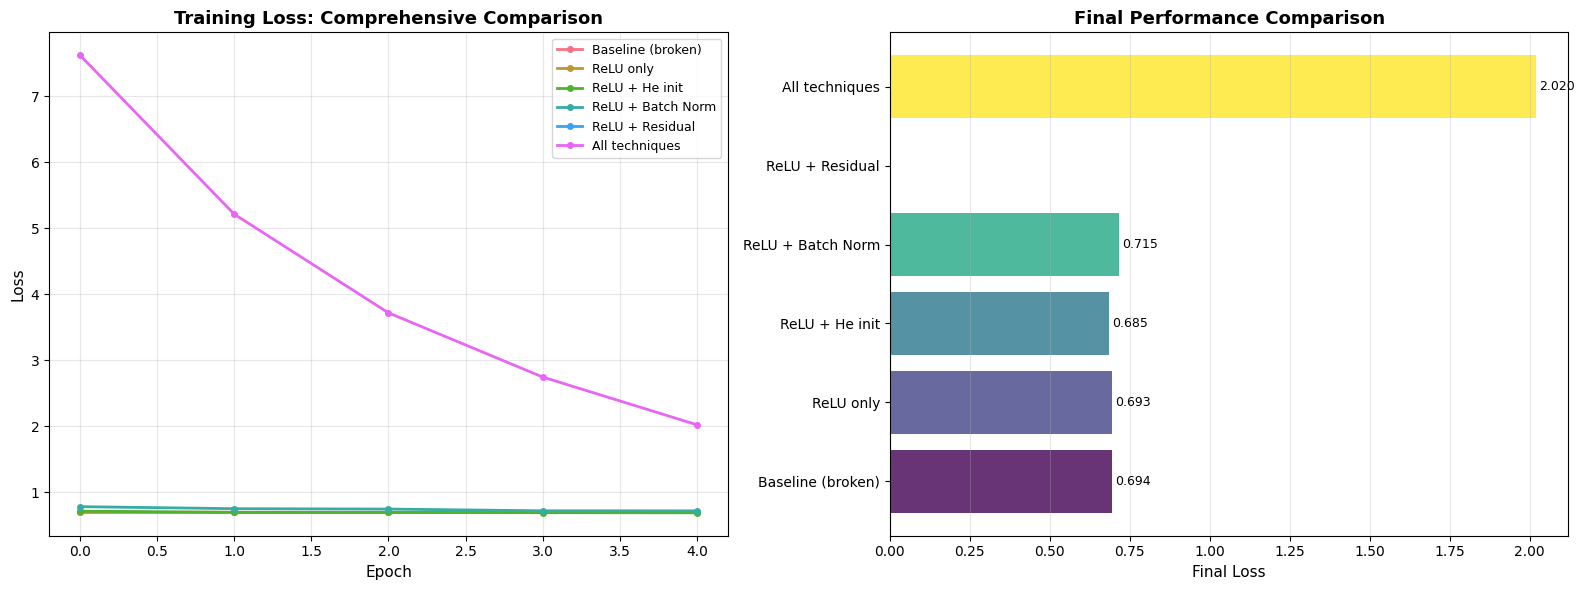

In [20]:
# Visualize comprehensive comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss curves
for name, data in comparison_results.items():
    ax1.plot(data['losses'], linewidth=2, label=name, marker='o', markersize=4)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training Loss: Comprehensive Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Final loss bar chart
names = list(comparison_results.keys())
final_losses = [comparison_results[name]['final_loss'] for name in names]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))

bars = ax2.barh(names, final_losses, color=colors, alpha=0.8)
ax2.set_xlabel('Final Loss', fontsize=11)
ax2.set_title('Final Performance Comparison', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Annotate bars
for i, (bar, loss) in enumerate(zip(bars, final_losses)):
    ax2.text(loss + 0.01, i, f'{loss:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Part 13: Practical Guidelines

### 🎯 Decision Tree for Gradient Stability

**Is your network deep (>10 layers)?**
- No → Standard initialization is fine, use ReLU
- Yes → Continue below

**Choosing activation:**
- ✅ Default: ReLU or Leaky ReLU
- ⚠️ Sigmoid/Tanh only if you really need outputs in specific ranges

**Initialization:**
- ReLU variants → He initialization
- Tanh/Sigmoid → Xavier/Glorot initialization
- Linear → Xavier initialization

**Normalization:**
- CNNs/MLPs → Batch Normalization
- RNNs/Transformers → Layer Normalization
- Small batches → Group Normalization or Layer Normalization

**Architecture:**
- Very deep (>20 layers) → Add residual connections
- Transformers → Always use residual connections

**Gradient clipping:**
- RNNs → Always use (e.g., max_norm=1.0)
- Other architectures → Use if training is unstable

### 📊 Summary Table

| Problem | Symptom | Solution |
|---------|---------|----------|
| Vanishing gradients | Early layers don't learn, loss plateaus | ReLU, Batch Norm, Residual connections |
| Exploding gradients | NaN loss, training diverges | Gradient clipping, better initialization |
| Deep network won't train | Loss doesn't decrease | Add residual connections + Batch Norm |
| Saturation | Activations all near 0 or 1 | ReLU instead of sigmoid/tanh |
| Dying ReLU | Many neurons output 0 | Use Leaky ReLU, lower learning rate |

### 🔬 Debugging Checklist

When your network isn't training:

1. **Check gradient magnitudes**
   - Too small (<1e-5): Vanishing → Use ReLU, add residual connections
   - Too large (>1000): Exploding → Add gradient clipping, fix initialization

2. **Visualize activations**
   - All near 0: Dying ReLU or bad initialization
   - All saturated (near min/max): Wrong activation function

3. **Try simpler version first**
   - Start with 3-5 layers
   - Once working, gradually add depth
   - Add complexity one technique at a time

## Part 14: Interactive Experiments

Now it's your turn to experiment! Modify the parameters below and observe the effects.

Configuration:
  num_layers          : 15
  activation          : relu
  init_strategy       : he
  use_batchnorm       : False
  use_residual        : False
  learning_rate       : 0.01
  gradient_clip       : None



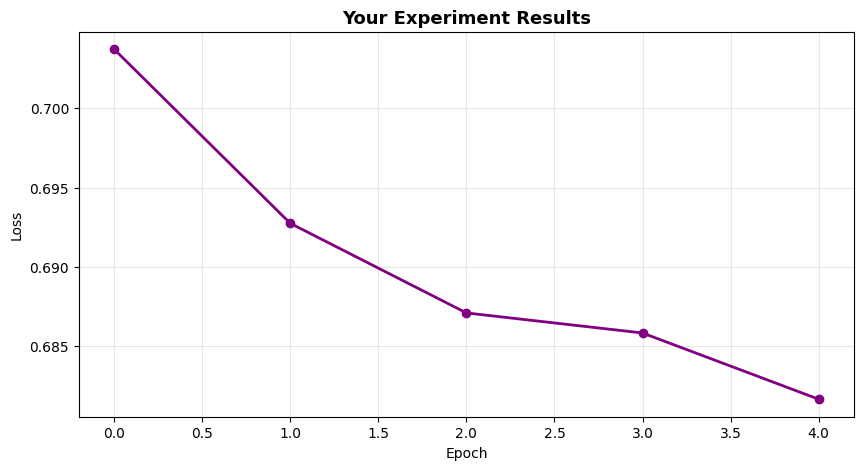

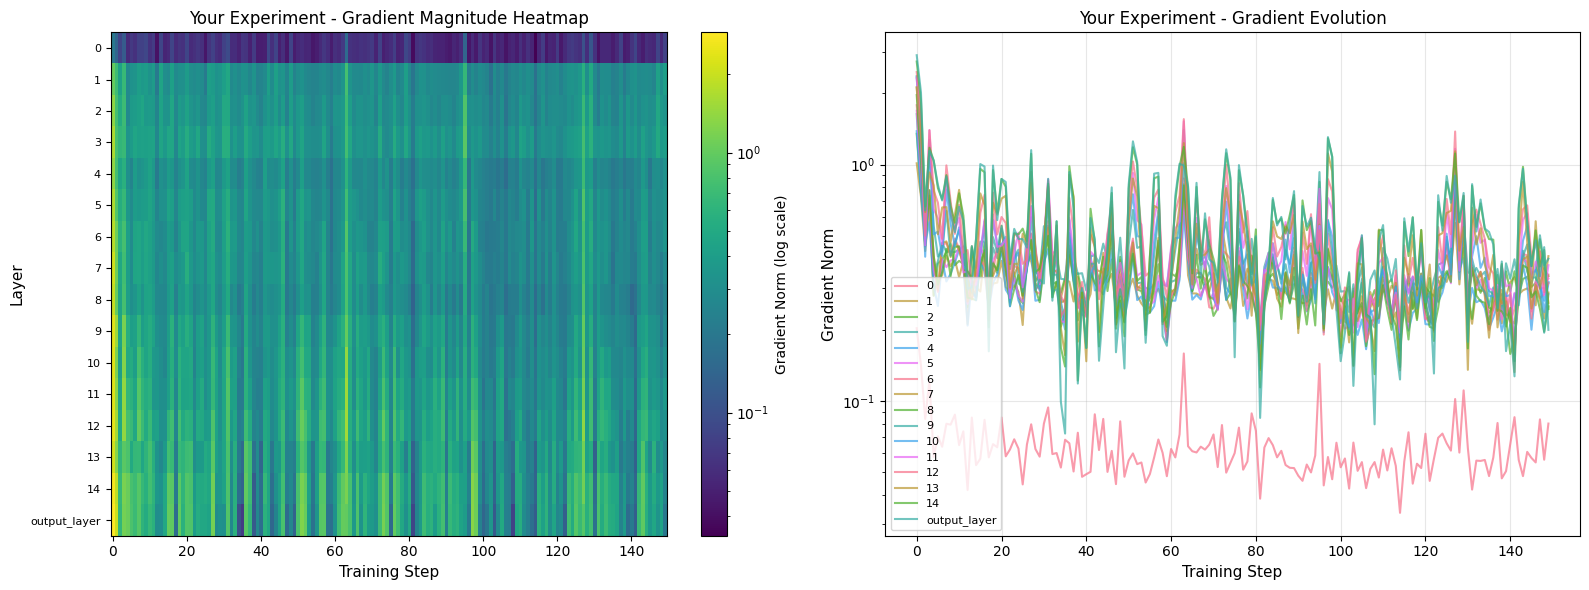


Final loss: 0.6816


In [21]:
# 🎮 EXPERIMENT PLAYGROUND - Modify these parameters!

EXPERIMENT_CONFIG = {
    'num_layers': 15,              # Try: 3, 10, 20, 50, 100
    'activation': 'relu',          # Try: 'sigmoid', 'tanh', 'relu', 'leaky_relu'
    'init_strategy': 'he',         # Try: 'default', 'xavier', 'he', 'small', 'large'
    'use_batchnorm': False,        # Try: True, False
    'use_residual': False,         # Try: True, False
    'learning_rate': 0.01,         # Try: 0.001, 0.01, 0.1
    'gradient_clip': None,         # Try: None, 0.5, 1.0, 5.0
}

# Run experiment
print("Configuration:")
for key, value in EXPERIMENT_CONFIG.items():
    print(f"  {key:20s}: {value}")
print()

experiment_model = FlexibleMLP(
    input_dim=2,
    hidden_dim=64,
    output_dim=2,
    num_layers=EXPERIMENT_CONFIG['num_layers'],
    activation=EXPERIMENT_CONFIG['activation'],
    init_strategy=EXPERIMENT_CONFIG['init_strategy'],
    use_batchnorm=EXPERIMENT_CONFIG['use_batchnorm'],
    use_residual=EXPERIMENT_CONFIG['use_residual']
)

exp_losses, exp_grad_history = train_with_tracking(
    experiment_model,
    train_loader,
    epochs=5,
    lr=EXPERIMENT_CONFIG['learning_rate'],
    gradient_clip=EXPERIMENT_CONFIG['gradient_clip']
)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(exp_losses, linewidth=2, marker='o', markersize=6, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Your Experiment Results', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

plot_gradient_flow(exp_grad_history, title="Your Experiment", max_steps=150)

print(f"\nFinal loss: {exp_losses[-1]:.4f}")

### 🎯 Suggested Experiments

Try these configurations and observe what happens:

1. **Extreme depth without help**
   - `num_layers=100, activation='relu', use_residual=False, use_batchnorm=False`
   - Prediction: Will it train? What will gradients look like?

2. **Extreme depth with help**
   - `num_layers=100, activation='relu', use_residual=True, use_batchnorm=True`
   - Compare with #1!

3. **Sigmoid comeback**
   - `num_layers=20, activation='sigmoid', use_batchnorm=True, use_residual=True`
   - Can we make sigmoid work with enough help?

4. **Learning rate sensitivity**
   - Try `learning_rate=0.001, 0.01, 0.1, 1.0` with same architecture
   - How does gradient clipping interact with high learning rates?

5. **Minimal working configuration**
   - Find the simplest setup (fewest techniques) that still trains well for 50 layers

## Part 15: Key Takeaways

### 🎓 What You've Learned

1. **The Problem**
   - Gradients multiply through layers via the chain rule
   - Factors <1 → vanishing, factors >1 → exploding
   - Depth amplifies these issues exponentially

2. **Vanishing Gradients**
   - **Cause**: Saturating activations (sigmoid/tanh), poor initialization
   - **Symptom**: Early layers don't learn, loss plateaus
   - **Solutions**: ReLU, Batch Norm, residual connections

3. **Exploding Gradients**
   - **Cause**: Large weights, accumulation of gradient growth
   - **Symptom**: Training diverges, NaN losses
   - **Solutions**: Gradient clipping, proper initialization

4. **Modern Deep Learning Recipe**
   ```python
   # For deep networks (>20 layers):
   activation = ReLU (or variants)
   initialization = He (for ReLU) or Xavier (for tanh)
   normalization = Batch Norm (or Layer Norm)
   architecture = Residual connections
   training = Gradient clipping if needed
   ```

5. **Intuition**
   - Gradients are information about how to improve the network
   - They need to flow backward through many layers
   - Each layer can amplify or attenuate this signal
   - Good architecture preserves gradient information

### 🚀 Next Steps

- Apply these techniques to real problems (image classification, NLP)
- Study advanced architectures (ResNet, Transformers) to see these principles in action
- Monitor gradient statistics during your own training runs
- Read the original papers: ResNet (He et al. 2015), Batch Norm (Ioffe & Szegedy 2015)

### 📚 Further Reading

- [Understanding the difficulty of training deep feedforward neural networks (Glorot & Bengio, 2010)](http://proceedings.mlr.press/v9/glorot10a.html)
- [Deep Residual Learning for Image Recognition (He et al., 2015)](https://arxiv.org/abs/1512.03385)
- [Batch Normalization (Ioffe & Szegedy, 2015)](https://arxiv.org/abs/1502.03167)
- [On the difficulty of training RNNs (Pascanu et al., 2013)](https://arxiv.org/abs/1211.5063)

## Congratulations! 🎉

You now have a deep understanding of gradient flow in neural networks. You've:
- ✅ Observed vanishing and exploding gradients firsthand
- ✅ Understood the mathematical causes
- ✅ Learned multiple solutions and when to apply them
- ✅ Built intuition through extensive experimentation

This knowledge is foundational to successfully training deep neural networks. Use it wisely!